In [75]:
# System & General Utilities
import os
import sys
import json
import warnings
from datetime import datetime

# Core Data Science & Numerical Tools
import numpy as np
import pandas as pd
import scipy.stats as stats

# Statistical Testing & Econometrics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Bayesian Modeling & Diagnostics
import pymc as pm
import arviz as az
import pytensor              # Required for pytensor.scan
import pytensor.tensor as pt # Required for tensor math (zeros_like, dot, etc.)

# Static Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# GCP Integrations
from google.cloud import bigquery, storage

# Global Notebook Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

In [76]:
# 1. Stream data from Google Sheet
sheet_url = "https://docs.google.com/spreadsheets/d/1Q1eEMwUtkcMW3_O7cWkeB2CPDWLuuad_TOTWIXDD8FY/export?format=csv&gid=0"
df = pd.read_csv(sheet_url)

# 2. Parse dates and clean currency/text formatting
df['week_start'] = pd.to_datetime(df['week_start'])

# ADDED 'inventory' to clean_cols
clean_cols = [
    'sales', 'inventory', 'gasregw', 'umcsent', 'search', 'display', 'social', 'pmax', 
    'fp_emails_sent', 'ott_cable', 'broadcast_audio', 'print', 'youtube', 
    'facebook_reels', 'facebook_add', 'direct_mail', 'broadcast_tv'
]

for col in clean_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Crop out unrecorded future weeks (post-July 2026) and missing/zero sales
df = df[(df['week_start'] <= '2026-07-27') & (df['sales'].notna()) & (df['sales'] > 0)].sort_values('week_start').reset_index(drop=True)

print(f"✅ Data Cleaned & Cropped! Valid Weeks: {len(df)} | Range: {df['week_start'].min().strftime('%Y-%m-%d')} to {df['week_start'].max().strftime('%Y-%m-%d')}")
df[['week_start', 'sales', 'inventory', 'eom_intensity', 'gasregw', 'umcsent']].head()

✅ Data Cleaned & Cropped! Valid Weeks: 104 | Range: 2024-08-05 to 2026-07-27


,week_start,sales,inventory,eom_intensity,gasregw,umcsent
0,2024-08-05,13.0000,246.1000,0.0000,3.4500,67.9000
1,2024-08-12,12.0000,238.1000,0.0000,3.4100,67.9000
2,2024-08-19,12.0000,236.7000,0.1429,3.3800,67.9000
3,2024-08-26,17.0000,230.6000,1.0000,3.3100,67.9000
4,2024-09-02,11.0000,222.3000,0.0000,3.2900,70.1000


=== Macro Correlation Check ===
Gas Price vs. Consumer Sentiment Correlation: -0.46

=== Driver Sparsity & Paid Spend Share ===
                 Zero_Weeks_Pct  Total_Volume_or_Spend  Mean_Weekly  \
broadcast_audio         93.2700             14999.9900     144.2300   
facebook_add            93.2700              7000.0200      67.3100   
display                 86.5400              2328.2000      22.3900   
broadcast_tv            81.7300             49621.1400     477.1300   
direct_mail             80.7700            127328.0000    1224.3100   
pmax                    75.9600              3115.8100      29.9600   
print                   75.9600             17720.0000     170.3800   
youtube                 67.3100             12249.9800     117.7900   
facebook_reels          53.8500             19750.0100     189.9000   
ott_cable               53.8500             63001.3700     605.7800   
fp_emails_sent           8.6500           1891918.0000   18191.5200   
search              

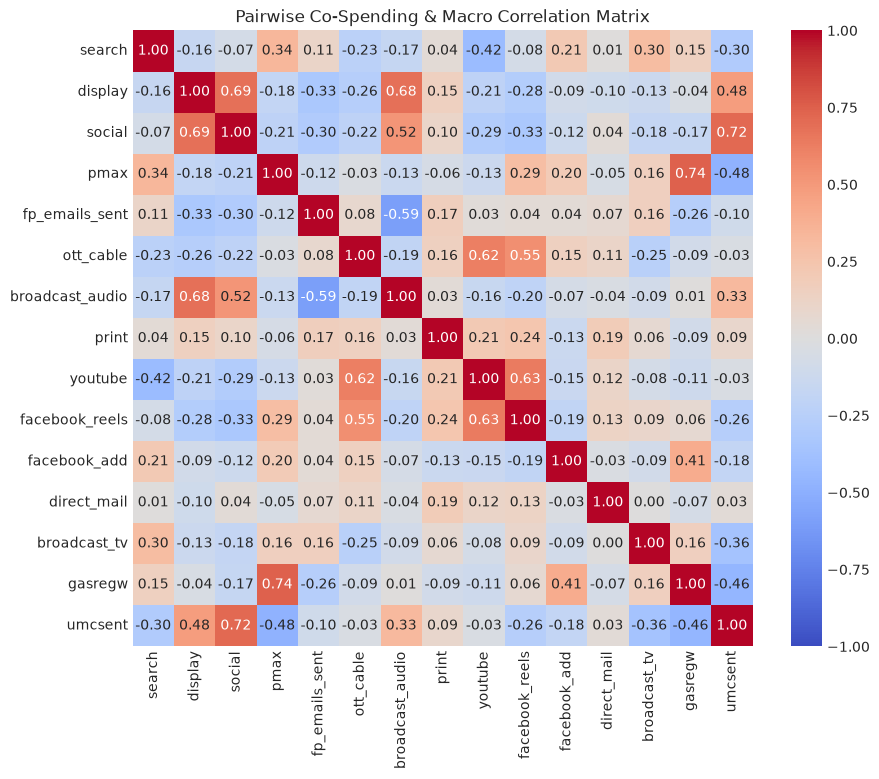

In [77]:
# List all sales drivers
all_drivers = [
    'search', 'display', 'social', 'pmax', 'fp_emails_sent', 'ott_cable',
    'broadcast_audio', 'print', 'youtube', 'facebook_reels', 'facebook_add',
    'direct_mail', 'broadcast_tv'
]
paid_spend_channels = [c for c in all_drivers if c != 'fp_emails_sent']

# 1. Macro Collinearity Assessment
macro_corr = df[['gasregw', 'umcsent']].corr().iloc[0, 1]
print(f"=== Macro Correlation Check ===")
print(f"Gas Price vs. Consumer Sentiment Correlation: {macro_corr:.2f}\n")

# 2. Sparsity & Paid Spend Share
sparsity_df = pd.DataFrame({
    'Zero_Weeks_Pct': (df[all_drivers] == 0).mean() * 100,
    'Total_Volume_or_Spend': df[all_drivers].sum(),
    'Mean_Weekly': df[all_drivers].mean(),
    'Spend_Share_Pct': (df[paid_spend_channels].sum() / df[paid_spend_channels].sum().sum()) * 100
}).sort_values('Zero_Weeks_Pct', ascending=False)

print("=== Driver Sparsity & Paid Spend Share ===")
print(sparsity_df.round(2))

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[all_drivers + ['gasregw', 'umcsent']].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pairwise Co-Spending & Macro Correlation Matrix")
plt.show()

In [78]:
# 1. Base design matrix including raw inventory
df_model = df[['week_start', 'sales', 'inventory', 'eom_intensity', 'fp_emails_sent']].copy()

# 2. Macro stress index (Gas Price Z-score - Sentiment Z-score)
gas_z = (df['gasregw'] - df['gasregw'].mean()) / df['gasregw'].std()
sent_z = (df['umcsent'] - df['umcsent'].mean()) / df['umcsent'].std()
df_model['macro_stress_index'] = gas_z - sent_z

# 3. ADDED: Standardized Inventory Index (Z-score)
df_model['inventory_index'] = (df['inventory'] - df['inventory'].mean()) / df['inventory'].std()

# 4. Consolidate 12 Paid Media Channels into 5 Strategic Buckets
df_model['fp_digital'] = df['search'] + df['pmax'] + df['display']
df_model['meta_social'] = df['social'] + df['facebook_reels'] + df['facebook_add']
df_model['digital_video_ott'] = df['youtube'] + df['ott_cable']
df_model['broadcast_media'] = df['broadcast_tv'] + df['broadcast_audio']
df_model['print_mail'] = df['direct_mail'] + df['print']

consolidated_paid = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']

print("=== Consolidated 5-Channel Sparsity Profile ===")
sparsity_check = pd.DataFrame({
    'Zero_Weeks_Pct': (df_model[consolidated_paid] == 0).mean() * 100,
    'Total_Spend': df_model[consolidated_paid].sum(),
    'Spend_Share_Pct': (df_model[consolidated_paid].sum() / df_model[consolidated_paid].sum().sum()) * 100
}).sort_values('Spend_Share_Pct', ascending=False)

print(sparsity_check.round(2))

=== Consolidated 5-Channel Sparsity Profile ===
                   Zero_Weeks_Pct  Total_Spend  Spend_Share_Pct
print_mail                65.3800  145048.0000          33.6900
fp_digital                 0.0000   95817.1200          22.2500
digital_video_ott         48.0800   75251.3500          17.4800
broadcast_media           75.0000   64621.1300          15.0100
meta_social                0.0000   49838.8500          11.5700


In [79]:
# Generate 52-week Annual Fourier Terms (Order k=2)
weeks = np.arange(len(df_model))
period = 52.1429

df_model['sin_order1'] = np.sin(2 * np.pi * 1 * weeks / period)
df_model['cos_order1'] = np.cos(2 * np.pi * 1 * weeks / period)
df_model['sin_order2'] = np.sin(2 * np.pi * 2 * weeks / period)
df_model['cos_order2'] = np.cos(2 * np.pi * 2 * weeks / period)

print(f"=== Final Model Matrix Verified ({df_model.shape[0]} rows, {df_model.shape[1]} columns) ===")
df_model[['week_start', 'sales', 'eom_intensity', 'macro_stress_index', 'fp_emails_sent', 'fp_digital']].head()

=== Final Model Matrix Verified (104 rows, 16 columns) ===


,week_start,sales,eom_intensity,macro_stress_index,fp_emails_sent,fp_digital
0,2024-08-05,13.0000,0.0000,-0.7279,0,947.0100
1,2024-08-12,12.0000,0.0000,-0.8214,0,928.0000
2,2024-08-19,12.0000,0.1429,-0.8915,0,1079.8700
3,2024-08-26,17.0000,1.0000,-1.0551,0,1104.4800
4,2024-09-02,11.0000,0.0000,-1.3696,0,937.3000


=== Fourier Terms vs. EOM Intensity (First 8 Weeks) ===
  week_start  eom_intensity  sin_order1  cos_order1  sin_order2  cos_order2
0 2024-08-05         0.0000      0.0000      1.0000      0.0000      1.0000
1 2024-08-12         0.0000      0.1202      0.9927      0.2387      0.9711
2 2024-08-19         0.1429      0.2387      0.9711      0.4635      0.8861
3 2024-08-26         1.0000      0.3537      0.9354      0.6616      0.7498
4 2024-09-02         0.0000      0.4635      0.8861      0.8215      0.5702
5 2024-09-09         0.0000      0.5667      0.8239      0.9338      0.3577
6 2024-09-16         0.0000      0.6616      0.7498      0.9922      0.1245
7 2024-09-23         0.7143      0.7470      0.6649      0.9933     -0.1159


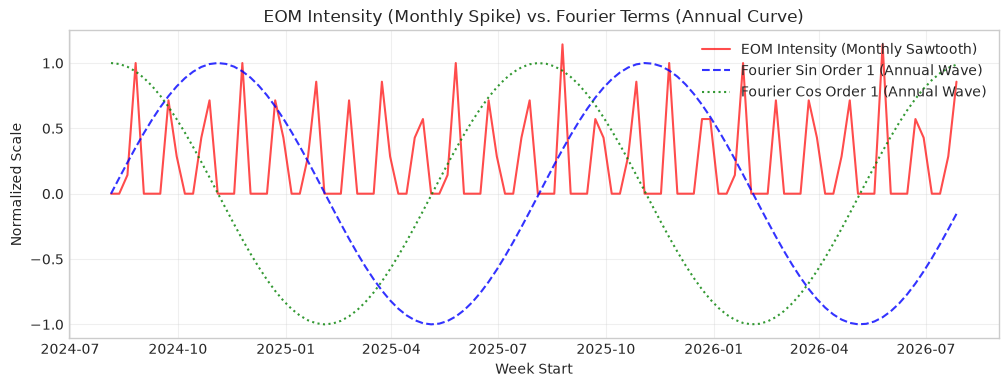

In [80]:
# 1. View the 4 Fourier columns alongside EOM intensity
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']
print("=== Fourier Terms vs. EOM Intensity (First 8 Weeks) ===")
print(df_model[['week_start', 'eom_intensity'] + fourier_cols].head(8).round(4))

# 2. Visual comparison of time frequencies
plt.figure(figsize=(12, 4))
plt.plot(df_model['week_start'], df_model['eom_intensity'], label='EOM Intensity (Monthly Sawtooth)', color='red', alpha=0.7, linewidth=1.5)
plt.plot(df_model['week_start'], df_model['sin_order1'], label='Fourier Sin Order 1 (Annual Wave)', color='blue', linestyle='--', alpha=0.8)
plt.plot(df_model['week_start'], df_model['cos_order1'], label='Fourier Cos Order 1 (Annual Wave)', color='green', linestyle=':', alpha=0.8)

plt.title("EOM Intensity (Monthly Spike) vs. Fourier Terms (Annual Curve)")
plt.xlabel("Week Start")
plt.ylabel("Normalized Scale")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

In [81]:
df_model


,week_start,sales,inventory,eom_intensity,fp_emails_sent,macro_stress_index,inventory_index,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail,sin_order1,cos_order1,sin_order2,cos_order2
0,2024-08-05,13.0000,246.1000,0.0000,0,-0.7279,1.0450,947.0100,418.8600,0.0000,1846.1500,0.0000,0.0000,1.0000,0.0000,1.0000
1,2024-08-12,12.0000,238.1000,0.0000,0,-0.8214,0.8644,928.0000,402.6800,0.0000,1846.1500,0.0000,0.1202,0.9927,0.2387,0.9711
2,2024-08-19,12.0000,236.7000,0.1429,0,-0.8915,0.8328,1079.8700,351.1800,0.0000,2461.5400,750.0000,0.2387,0.9711,0.4635,0.8861
3,2024-08-26,17.0000,230.6000,1.0000,0,-1.0551,0.6951,1104.4800,497.1500,0.0000,1846.1500,0.0000,0.3537,0.9354,0.6616,0.7498
4,2024-09-02,11.0000,222.3000,0.0000,0,-1.3696,0.5077,937.3000,419.7700,0.0000,0.0000,0.0000,0.4635,0.8861,0.8215,0.5702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,2026-06-29,9.0000,289.9000,0.4286,16539,2.4000,2.0338,1096.0500,396.8000,0.0000,0.0000,0.0000,-0.5947,0.8039,-0.9562,0.2926
100,2026-07-06,20.0000,287.6000,0.0000,17064,1.5893,1.9819,978.8500,130.7100,0.0000,0.0000,0.0000,-0.4938,0.8696,-0.8588,0.5124
101,2026-07-13,11.0000,284.6000,0.0000,21244,1.7762,1.9142,1142.8400,1690.6400,0.0000,0.0000,0.0000,-0.3857,0.9226,-0.7117,0.7025
102,2026-07-20,12.0000,290.9000,0.2857,22019,2.1034,2.0564,1282.0600,1700.7300,3818.5000,0.0000,0.0000,-0.2720,0.9623,-0.5234,0.8521


In [82]:
# ==============================================================================
# CELL 1: Prior Hyperparameters Configuration
# ==============================================================================

# List of media channels in exact model matrix order
media_channels = [
    'fp_digital', 
    'meta_social', 
    'digital_video_ott', 
    'broadcast_media', 
    'print_mail'
]

priors_config = {
    # Baseline Intercept (as % of mean weekly sales)
    "intercept": {"mu": 1.0, "sigma": 0.2},
    
    # Adstock Decay & Hill Saturation parameters
    "adstock_alpha": {"alpha": 2.0, "beta": 5.0}, # Beta distribution for decay
    "hill_half_sat": {"alpha": 3.0, "beta": 3.0}, # Gamma distribution for half-saturation
    "hill_slope":    {"alpha": 3.0, "beta": 1.0}, # Gamma distribution for Hill slope
    
    # -------------------------------------------------------------------------
    # INDIVIDUAL MEDIA CHANNEL PRIORS (HalfNormal sigma per channel)
    # Higher sigma = higher expected lift potential or higher uncertainty
    # -------------------------------------------------------------------------
    "beta_media_by_channel": {
        "fp_digital":        {"sigma": 0.15}, # e.g. First-party digital / search
        "meta_social":       {"sigma": 0.10}, # e.g. Meta paid social / reels
        "digital_video_ott": {"sigma": 0.08}, # e.g. OTT / YouTube
        "broadcast_media":   {"sigma": 0.05}, # e.g. TV & Audio (broader reach)
        "print_mail":        {"sigma": 0.05}  # e.g. Direct Mail & Print
    },
    
    # Controls & External Drivers
    "beta_inventory":    {"sigma": 0.15},        # Stock availability constraint
    "beta_eom":          {"sigma": 0.15},        # End-of-month promotion boost
    "beta_macro":        {"mu": 0.0, "sigma": 0.10}, # Macroeconomic stress index
    "beta_fourier":      {"mu": 0.0, "sigma": 0.10}, # Seasonality (sin/cos terms)
    
    # Observation Noise
    "sigma":             {"lam": 10.0}
}

In [85]:
# ==============================================================================
# 1. CHANNEL-SPECIFIC PRIOR & ADSTOCK CONFIGURATION
# ==============================================================================

media_channels = [
    'fp_digital', 
    'meta_social', 
    'digital_video_ott', 
    'broadcast_media', 
    'print_mail'
]

fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

priors_config = {
    # Baseline Intercept (% of mean weekly sales)
    "intercept": {"mu": 1.0, "sigma": 0.20},
    
    # Channel-Specific Parameters (Adstock Alpha, L_max, Beta Sigma, Hill K, Hill S)
    "channels": {
        "fp_digital":        {"alpha": 0.20, "l_max": 3, "beta_sigma": 0.15, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
        "meta_social":       {"alpha": 0.25, "l_max": 3, "beta_sigma": 0.12, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
        "digital_video_ott": {"alpha": 0.40, "l_max": 4, "beta_sigma": 0.10, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
        "broadcast_media":   {"alpha": 0.50, "l_max": 6, "beta_sigma": 0.08, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
        "print_mail":        {"alpha": 0.60, "l_max": 8, "beta_sigma": 0.08, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
    },
    
    # Control Variable Priors
    "beta_inventory": {"sigma": 0.15},
    "beta_eom":       {"sigma": 0.15},
    "beta_macro":     {"mu": 0.0, "sigma": 0.10},
    "beta_fourier":   {"sigma": 0.10}
}


# ==============================================================================
# 2. DATA PRE-FLIGHT & FAST ADSTOCK TRANSFORMATION
# ==============================================================================

def apply_fast_adstock(df, channel_cols, config):
    """Applies 1D convolution adstocking to specified media columns."""
    adstocked_df = df.copy()
    for col in channel_cols:
        alpha = config["channels"][col]["alpha"]
        l_max = config["channels"][col]["l_max"]
        if alpha > 0:
            x = df[col].values
            weights = np.power(alpha, np.arange(l_max))
            weights /= weights.sum()
            adstocked_df[col] = np.convolve(x, weights)[:len(x)]
    return adstocked_df

def hill_function(x, k, s):
    """Calculates vectorised Hill saturation."""
    return (x**s) / (k**s + x**s + 1e-8)

# Normalize Target (Sales) & Media Spend by sample means
sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

df_scaled_media = df_model[media_channels].copy()
for col in media_channels:
    c_mean = df_scaled_media[col].mean()
    if c_mean > 0:
        df_scaled_media[col] = df_scaled_media[col] / c_mean

# Apply Fast Convolution Adstock
df_adstocked = apply_fast_adstock(df_scaled_media, media_channels, priors_config)

# Extract Channel Prior Arrays for PyMC
beta_sigmas = np.array([priors_config["channels"][c]["beta_sigma"] for c in media_channels])
k_alphas    = np.array([priors_config["channels"][c]["k_alpha"] for c in media_channels])
k_betas     = np.array([priors_config["channels"][c]["k_beta"] for c in media_channels])
s_alphas    = np.array([priors_config["channels"][c]["s_alpha"] for c in media_channels])
s_betas     = np.array([priors_config["channels"][c]["s_beta"] for c in media_channels])


# ==============================================================================
# 3. PYMC BAYESIAN MODEL DEFINITION
# ==============================================================================

with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": media_channels,
    "fourier_term": fourier_cols
}) as mmm_model:

    # --- Data Containers ---
    media = pm.Data("media", df_adstocked[media_channels].values, dims=("obs_id", "channel"))
    fourier = pm.Data("fourier", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
    inv_idx_data = pm.Data("inv_idx_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
    macro_data = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")
    sales_obs = pm.Data("sales_obs", y_scaled, dims="obs_id")

    # --- Baseline Intercept ---
    intercept = pm.Normal(
        "intercept", 
        mu=priors_config["intercept"]["mu"], 
        sigma=priors_config["intercept"]["sigma"]
    )

    # --- Media Channel Priors ---
    beta_channel = pm.HalfNormal("beta_channel", sigma=beta_sigmas, dims="channel")
    k_val = pm.Gamma("k_val", alpha=k_alphas, beta=k_betas, dims="channel")
    s_val = pm.Gamma("s_val", alpha=s_alphas, beta=s_betas, dims="channel")

    # --- Control Priors ---
    b_inv = pm.HalfNormal("beta_inv", sigma=priors_config["beta_inventory"]["sigma"])
    b_eom = pm.HalfNormal("beta_eom", sigma=priors_config["beta_eom"]["sigma"])
    b_macro = pm.Normal(
        "beta_macro", 
        mu=priors_config["beta_macro"]["mu"], 
        sigma=priors_config["beta_macro"]["sigma"]
    )
    b_fourier = pm.Normal(
        "beta_fourier", 
        mu=0.0, 
        sigma=priors_config["beta_fourier"]["sigma"], 
        dims="fourier_term"
    )

    # --- Media Contribution (Hill Transformation * Beta) ---
    media_saturated = hill_function(media, k_val, s_val)
    media_contrib = pt.sum(media_saturated * beta_channel, axis=1)

    # --- Linear Predictor (mu) ---
    mu = pm.Deterministic(
        "mu",
        intercept 
        + media_contrib 
        + (b_inv * inv_idx_data) 
        + (b_eom * eom_data) 
        + (b_macro * macro_data) 
        + pm.math.dot(fourier, b_fourier),
        dims="obs_id"
    )

    # --- Robust Student-T Likelihood ---
    nu = pm.Exponential("nu", lam=0.1) + 3
    sigma = pm.Exponential("sigma", lam=1.0)
    
    pm.StudentT(
        "likelihood", 
        nu=nu, 
        mu=mu, 
        sigma=sigma, 
        observed=sales_obs, 
        dims="obs_id"
    )

# ==============================================================================
# 4. MCMC SAMPLING & POSTERIOR PREDICTIVE
# ==============================================================================

with mmm_model:
    print("🚀 Sampling Standalone Dealership Model...")
    idata = pm.sample(
        draws=250, 
        tune=250, 
        chains=4, 
        target_accept=0.95, 
        random_seed=42
    )
    pm.compute_log_likelihood(idata)
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

print("✅ Model execution completed successfully.")

🚀 Sampling Standalone Dealership Model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_val, s_val, beta_inv, beta_eom, beta_macro, beta_fourier, nu, sigma]


Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 14 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [likelihood]


✅ Model execution completed successfully.


1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK
Total Divergent Transitions: 0
✅ No divergences detected. Sampler geometry is healthy.
Max R-hat (Target <= 1.05): 1.012
Min Bulk ESS (Target > 200): 274.2
🚀 ALL CONVERGENCE CHECKS PASSED! Posterior estimates are reliable.

--- Summary Table (Scaled Parameters) ---


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.8323,0.0625,0.7258,0.9214,657.7983,658.9402,1.0050,0.0026,0.0028
beta_channel[fp_digital],0.0850,0.0706,0.0077,0.2177,828.2784,677.3272,1.0026,0.0022,0.0026
beta_channel[meta_social],0.0622,0.0494,0.0066,0.1577,896.9811,675.4560,1.0019,0.0014,0.0016
beta_channel[digital_video_ott],0.0552,0.0442,0.0044,0.1387,693.3144,452.1006,1.0069,0.0014,0.0013
beta_channel[broadcast_media],0.0513,0.0388,0.0047,0.1234,804.2243,504.4754,1.0098,0.0011,0.0011
beta_channel[print_mail],0.0883,0.0562,0.0083,0.1834,274.1874,166.2677,1.0077,0.0026,0.0018
k_val[fp_digital],1.1250,0.6255,0.2952,2.2524,1292.3842,817.9727,1.0086,0.0163,0.0185
k_val[meta_social],1.0776,0.6048,0.3022,2.1734,1285.5527,564.5517,1.0098,0.0157,0.0190
k_val[digital_video_ott],1.1383,0.6190,0.3635,2.3389,1120.1257,606.3319,1.0018,0.0167,0.0177
k_val[broadcast_media],1.0288,0.5858,0.3148,2.1493,940.8764,636.4133,1.0009,0.0168,0.0162



2. CHANNEL LIFT & BASELINE PARAMETERS (UNSCALED TO VEHICLE UNITS)
Baseline Sales (Intercept): 11.68 vehicles / week (Sample Mean = 14.04)


,Channel,Average Weekly Spend ($),Max Sales Lift (Vehicles/Wk),Half-Saturation (k),Hill Slope (s)
0,fp_digital,$921.32,1.19,1.12,2.91
1,meta_social,$479.22,0.87,1.08,2.80
2,digital_video_ott,$723.57,0.78,1.14,2.94
3,broadcast_media,$621.36,0.72,1.03,2.89
4,print_mail,"$1,394.69",1.24,1.04,3.38



3. MODEL FIT & ACCURACY METRICS
Model R-Squared (R²): 0.181
Mean Absolute Percentage Error (MAPE): 24.55%
Root Mean Squared Error (RMSE): 3.68 vehicles

4. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)
ELPD LOO: -18.13 (SE: 6.71)
Max Pareto k (Target < 0.7): 0.39
✅ Pareto k values are good. Out-of-sample prediction is reliable.


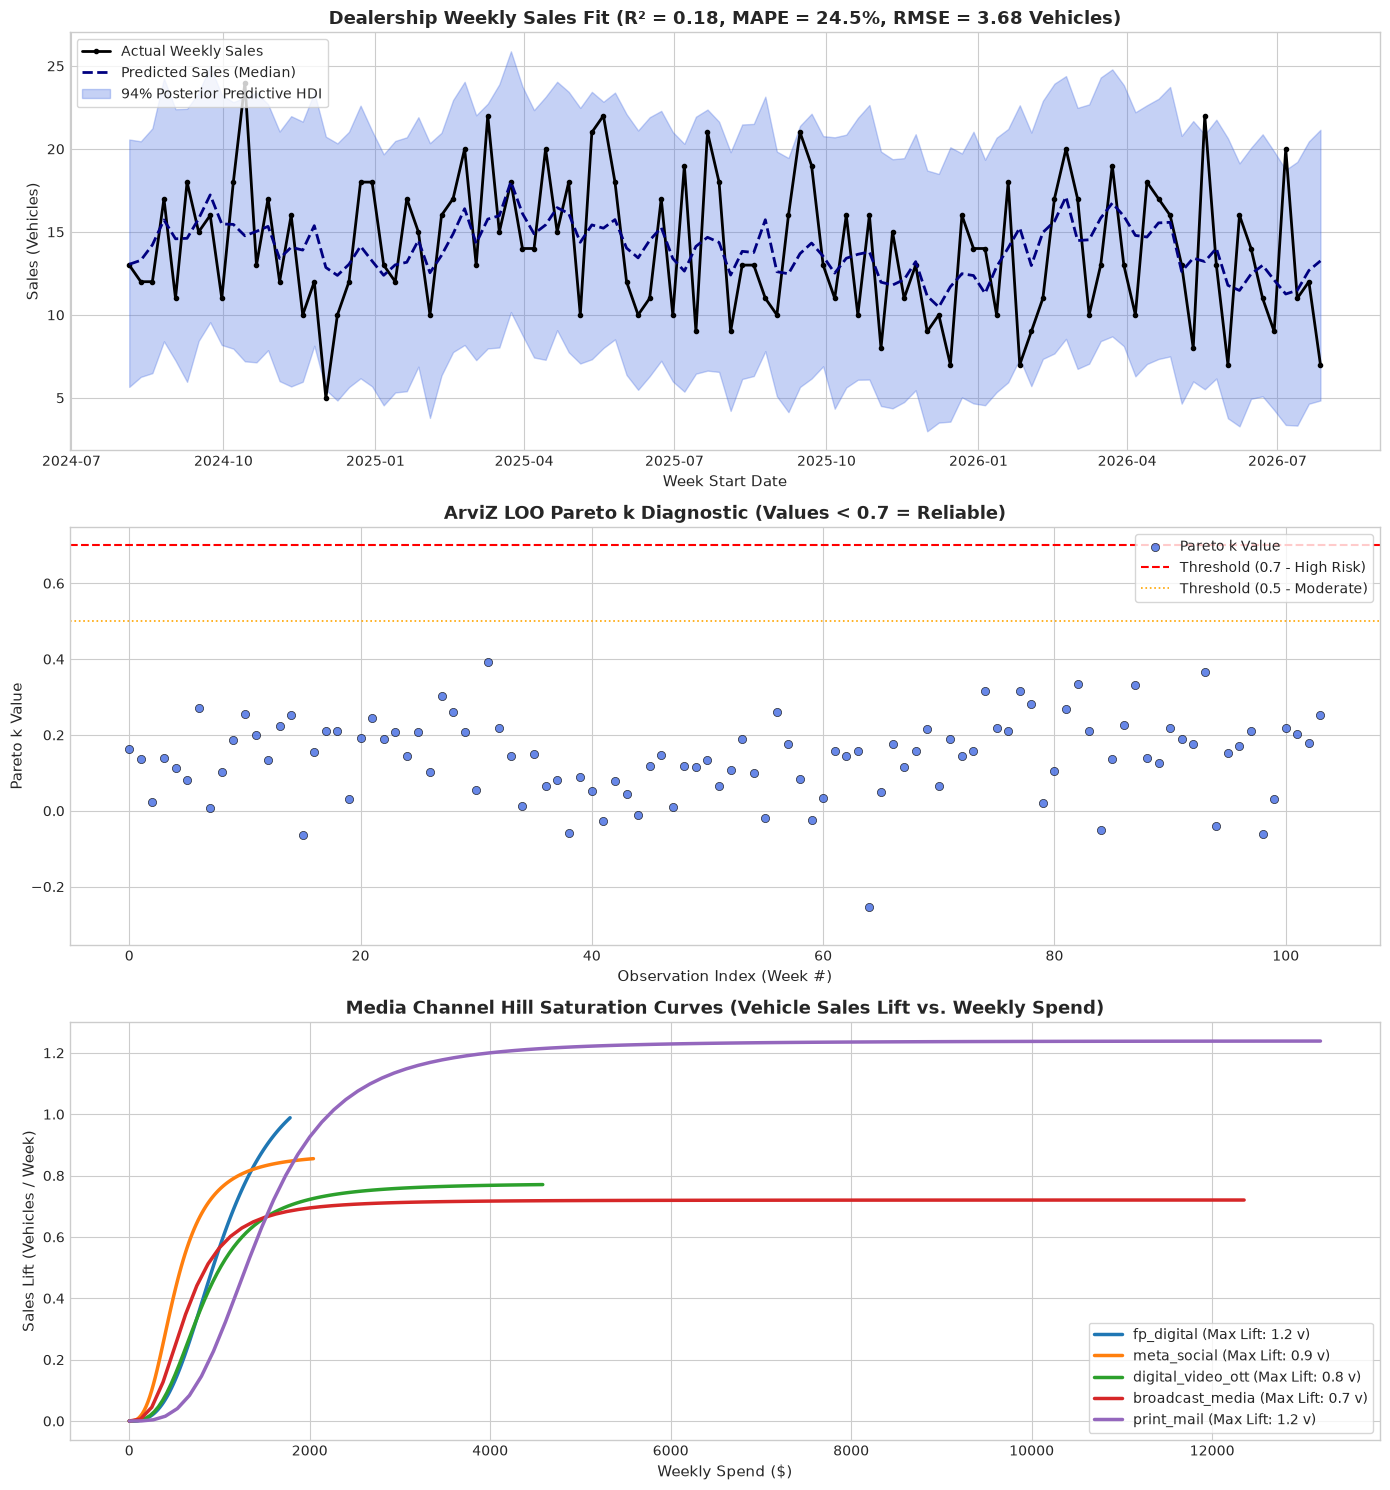

In [91]:
# ==============================================================================
# 1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK
# ==============================================================================

print("=" * 80)
print("1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK")
print("=" * 80)

# Extract divergences
divergences = idata.sample_stats["divergences"].values.sum()
print(f"Total Divergent Transitions: {divergences}")
if divergences > 0:
    print("⚠️ WARNING: Divergences detected. Consider increasing target_accept (e.g., 0.98).")
else:
    print("✅ No divergences detected. Sampler geometry is healthy.")

# ArviZ Summary for key parameters
summary_stats = az.summary(
    idata, 
    var_names=["intercept", "beta_channel", "k_val", "s_val", "beta_inv", "beta_eom", "beta_macro", "sigma"]
)

# Check R-hat and ESS thresholds
max_rhat = summary_stats["r_hat"].max()
min_ess = summary_stats["ess_bulk"].min()

print(f"Max R-hat (Target <= 1.05): {max_rhat:.3f}")
print(f"Min Bulk ESS (Target > 200): {min_ess:.1f}")

if max_rhat <= 1.05 and min_ess >= 200 and divergences == 0:
    print("🚀 ALL CONVERGENCE CHECKS PASSED! Posterior estimates are reliable.")
else:
    print("⚠️ Convergence warnings present. Inspect summary table below before making business decisions.")

print("\n--- Summary Table (Scaled Parameters) ---")
# Convert to standard DataFrame to avoid Jinja2 styling errors if Jinja2 isn't installed
display(pd.DataFrame(summary_stats))


# ==============================================================================
# 2. CHANNEL LIFT & BASELINE PARAMETERS
# ==============================================================================

print("\n" + "=" * 80)
print("2. CHANNEL LIFT & BASELINE PARAMETERS (UNSCALED TO VEHICLE UNITS)")
print("=" * 80)

post = idata.posterior.mean(dim=["chain", "draw"])

# Intercept in actual vehicles / week
baseline_vehicles = float(post["intercept"].values) * sales_mean

# Unscaled Beta Channel (Max weekly sales lift in vehicles)
beta_channel_means = post["beta_channel"].values * sales_mean

channel_summary_list = []
for i, chan in enumerate(media_channels):
    k_mean = float(post["k_val"].values[i])
    s_mean = float(post["s_val"].values[i])
    beta_veh = float(beta_channel_means[i])
    avg_spend = df_model[chan].mean()
    
    channel_summary_list.append({
        "Channel": chan,
        "Average Weekly Spend ($)": f"${avg_spend:,.2f}",
        "Max Sales Lift (Vehicles/Wk)": f"{beta_veh:.2f}",
        "Half-Saturation (k)": f"{k_mean:.2f}",
        "Hill Slope (s)": f"{s_mean:.2f}"
    })

channel_summary_df = pd.DataFrame(channel_summary_list)
print(f"Baseline Sales (Intercept): {baseline_vehicles:.2f} vehicles / week (Sample Mean = {sales_mean:.2f})")
display(channel_summary_df)


# ==============================================================================
# 3. MODEL FIT & ACCURACY METRICS
# ==============================================================================

print("\n" + "=" * 80)
print("3. MODEL FIT & ACCURACY METRICS")
print("=" * 80)

# Extract PPC samples (unscaled back to vehicle units)
ppc_samples = idata.posterior_predictive["likelihood"].values.reshape(-1, len(df_model)) * sales_mean
actual_sales = df_model['sales'].values

pred_median = np.median(ppc_samples, axis=0)
pred_lower = np.percentile(ppc_samples, 3, axis=0)   # 94% HDI Lower Bound
pred_upper = np.percentile(ppc_samples, 97, axis=0)  # 94% HDI Upper Bound

# Accuracy Metrics
mape = np.mean(np.abs((actual_sales - pred_median) / (actual_sales + 1e-9))) * 100
rmse = np.sqrt(np.mean((actual_sales - pred_median) ** 2))

# Robust NumPy R-Squared Calculation (1 - SS_res / SS_tot)
ss_res = np.sum((actual_sales - pred_median) ** 2)
ss_tot = np.sum((actual_sales - np.mean(actual_sales)) ** 2)
r2 = float(1.0 - (ss_res / ss_tot))

print(f"Model R-Squared (R²): {r2:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} vehicles")

# ==============================================================================
# 4. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)
# ==============================================================================
print("\n" + "=" * 80)
print("4. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)")
print("=" * 80)

# Compute LOO-CV metrics
loo_res = az.loo(idata)

# 1. Safely extract ELPD score (supports both new 'elpd' and legacy 'elpd_loo' attributes)
if hasattr(loo_res, "elpd"):
    elpd_val = float(loo_res.elpd)
elif hasattr(loo_res, "elpd_loo"):
    elpd_val = float(loo_res.elpd_loo)
else:
    elpd_val = float(loo_res[0])

# 2. Safely extract Standard Error (SE)
if hasattr(loo_res, "se"):
    se_val = float(loo_res.se)
else:
    se_val = float(loo_res["se"])

# 3. Safely extract Pareto k diagnostic values
if hasattr(loo_res, "pareto_k"):
    pareto_k_vals = loo_res.pareto_k
elif hasattr(loo_res, "khat"):
    pareto_k_vals = loo_res.khat
else:
    pareto_k_vals = loo_res["pareto_k"]

# Extract the maximum Pareto k value across NumPy / xarray data types
if hasattr(pareto_k_vals, "values"):
    max_k = float(np.max(pareto_k_vals.values))
else:
    max_k = float(np.max(pareto_k_vals))

# Display results
print(f"ELPD LOO: {elpd_val:.2f} (SE: {se_val:.2f})")
print(f"Max Pareto k (Target < 0.7): {max_k:.2f}")

if max_k < 0.7:
    print("✅ Pareto k values are good. Out-of-sample prediction is reliable.")
else:
    print("⚠️ High Pareto k values detected. Some observations may be influential outliers.")


# ==============================================================================
# 5. VISUALIZATION DASHBOARD (VERSION-PROOF MATPLOTLIB IMPLEMENTATION)
# ==============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# --- Panel 1: Actual vs Predicted Sales Time Series ---
dates = pd.to_datetime(df_model['week_start'])

axes[0].plot(dates, actual_sales, color='black', linewidth=2, label='Actual Weekly Sales', marker='o', markersize=3)
axes[0].plot(dates, pred_median, color='navy', linestyle='--', linewidth=2, label='Predicted Sales (Median)')
axes[0].fill_between(dates, pred_lower, pred_upper, color='royalblue', alpha=0.3, label='94% Posterior Predictive HDI')

axes[0].set_title(f"Dealership Weekly Sales Fit (R² = {r2:.2f}, MAPE = {mape:.1f}%, RMSE = {rmse:.2f} Vehicles)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Sales (Vehicles)", fontsize=11)
axes[0].set_xlabel("Week Start Date", fontsize=11)
axes[0].legend(loc='upper left', frameon=True)

# --- Panel 2: Pareto k Diagnostic Plot (Custom Matplotlib Implementation) ---
# Safely extract Pareto k values from LOO-CV results
pareto_k_vals = loo_res["pareto_k"]
if hasattr(pareto_k_vals, "values"):
    k_vals = pareto_k_vals.values
else:
    k_vals = np.asarray(pareto_k_vals)

indices = np.arange(len(k_vals))

# Plot Pareto k scatter points
axes[1].scatter(indices, k_vals, alpha=0.8, color='royalblue', edgecolor='black', linewidth=0.5, s=35, label='Pareto k Value')

# Add threshold lines at 0.5 and 0.7
axes[1].axhline(0.7, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.7 - High Risk)')
axes[1].axhline(0.5, color='orange', linestyle=':', linewidth=1.2, label='Threshold (0.5 - Moderate)')

axes[1].set_title("ArviZ LOO Pareto k Diagnostic (Values < 0.7 = Reliable)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Pareto k Value", fontsize=11)
axes[1].set_xlabel("Observation Index (Week #)", fontsize=11)
axes[1].legend(loc='upper right', frameon=True)
axes[1].set_ylim(bottom=min(-0.1, float(np.min(k_vals)) - 0.1))

# --- Panel 3: Media Channel Saturation / Hill Lift Curves ---
for chan in media_channels:
    max_spend = df_model[chan].max() * 1.2
    if max_spend == 0:
        max_spend = 1000.0
    x_spend_grid = np.linspace(0, max_spend, 100)
    
    # Calculate Hill Saturation Lift in Vehicles
    chan_idx = media_channels.index(chan)
    c_mean = df_model[chan].mean()
    if c_mean == 0:
        c_mean = 1.0
    
    scaled_x = x_spend_grid / c_mean
    k_val = float(post["k_val"].values[chan_idx])
    s_val = float(post["s_val"].values[chan_idx])
    beta_veh = float(beta_channel_means[chan_idx])
    
    y_lift = (scaled_x**s_val) / (scaled_x**s_val + k_val**s_val + 1e-8) * beta_veh
    axes[2].plot(x_spend_grid, y_lift, label=f"{chan} (Max Lift: {beta_veh:.1f} v)", linewidth=2.5)

axes[2].set_title("Media Channel Hill Saturation Curves (Vehicle Sales Lift vs. Weekly Spend)", fontsize=13, fontweight='bold')
axes[2].set_ylabel("Sales Lift (Vehicles / Week)", fontsize=11)
axes[2].set_xlabel("Weekly Spend ($)", fontsize=11)
axes[2].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

CHANNEL COST-EFFICIENCY & VEHICLE ACQUISITION TABLE
          Channel Avg Spend ($/Wk) Max Lift (Vehicles) Lift at Avg Spend Cost Per Vehicle ($) Vehicles / $1k Spend
      meta_social          $479.22                0.87              0.39            $1,225.41                 0.82
  broadcast_media          $621.36                0.72              0.35            $1,798.43                 0.56
       fp_digital          $921.32                1.19              0.50            $1,859.78                 0.54
digital_video_ott          $723.57                0.78              0.31            $2,298.73                 0.44
       print_mail        $1,394.69                1.24              0.58            $2,412.67                 0.41


ValueError: Keyword arguments ['hdi_prob', 'ax'] have been passed as **kwargs but have no active aesthetic mapped to them. Keyword arguments must define values to use in their respective aesthetic mapping.

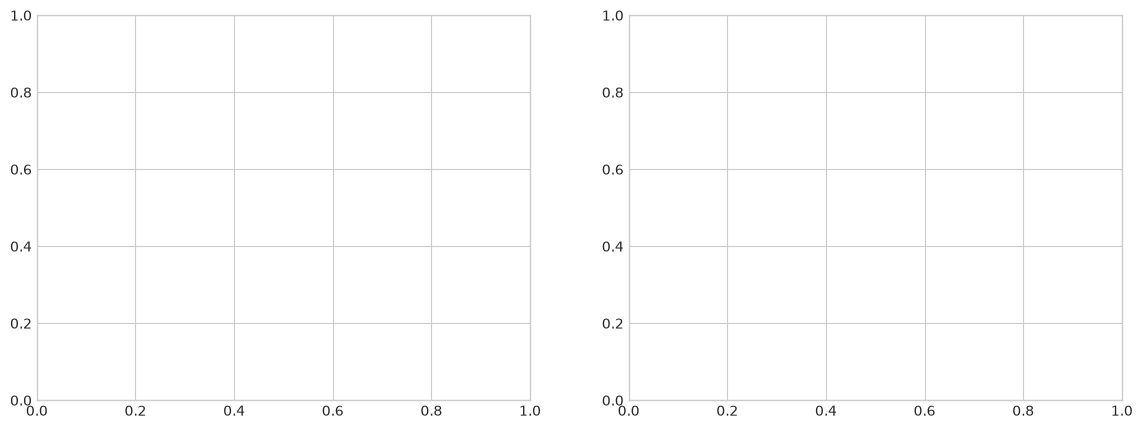

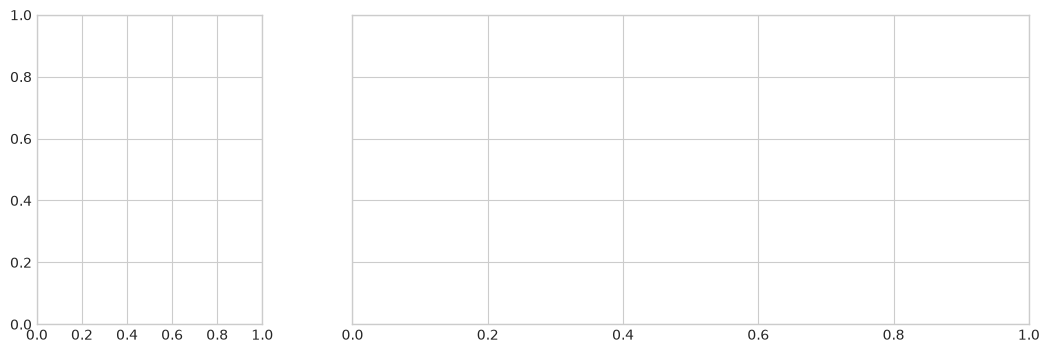

In [92]:
# ==============================================================================
# POST-RUN ANALYSIS: CHANNEL EFFICIENCY & UNCERTAINTY DASHBOARD
# ==============================================================================

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. CALCULATE COST PER VEHICLE ACQUIRED (CPA) & EFFICIENCY
# ------------------------------------------------------------------------------
post = idata.posterior.mean(dim=["chain", "draw"])
beta_channel_means = post["beta_channel"].values * sales_mean

efficiency_records = []
for i, chan in enumerate(media_channels):
    avg_spend = df_model[chan].mean()
    if avg_spend == 0:
        avg_spend = 1.0
    
    # Evaluate Hill function at average weekly spend (scaled x = 1.0)
    k_val = float(post["k_val"].values[i])
    s_val = float(post["s_val"].values[i])
    max_lift_veh = float(beta_channel_means[i])
    
    # Scaled x = 1.0 at average spend
    x_scaled = 1.0
    lift_at_avg = (x_scaled**s_val) / (x_scaled**s_val + k_val**s_val + 1e-8) * max_lift_veh
    
    cost_per_vehicle = avg_spend / (lift_at_avg + 1e-9)
    vehicles_per_1k = (lift_at_avg / avg_spend) * 1000.0 if avg_spend > 0 else 0
    
    efficiency_records.append({
        "Channel": chan,
        "Avg Spend ($/Wk)": avg_spend,
        "Max Lift (Vehicles)": max_lift_veh,
        "Lift at Avg Spend": lift_at_avg,
        "Cost Per Vehicle ($)": cost_per_vehicle,
        "Vehicles / $1k Spend": vehicles_per_1k
    })

efficiency_df = pd.DataFrame(efficiency_records).sort_values("Cost Per Vehicle ($)")

print("=" * 80)
print("CHANNEL COST-EFFICIENCY & VEHICLE ACQUISITION TABLE")
print("=" * 80)
print(efficiency_df.to_string(index=False, formatters={
    "Avg Spend ($/Wk)": "${:,.2f}".format,
    "Max Lift (Vehicles)": "{:.2f}".format,
    "Lift at Avg Spend": "{:.2f}".format,
    "Cost Per Vehicle ($)": "${:,.2f}".format,
    "Vehicles / $1k Spend": "{:.2f}".format
}))


# ------------------------------------------------------------------------------
# 2. PLOT POSTERIOR BETA UNCERTAINTY (FOREST PLOT)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Forest plot of beta_channel
az.plot_forest(
    idata,
    var_names=["beta_channel"],
    combined=True,
    hdi_prob=0.89,
    ax=axes[0]
)
axes[0].set_title("89% Posterior HDI for Channel Betas (Scaled)", fontsize=12, fontweight='bold')
axes[0].set_yticklabels(reversed(media_channels))

# Bar chart of Cost Per Vehicle
bars = axes[1].barh(efficiency_df["Channel"], efficiency_df["Cost Per Vehicle ($)"], color='skyblue', edgecolor='black')
axes[1].set_title("Cost Per Vehicle Acquired ($ / Vehicle)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Cost ($)", fontsize=10)
axes[1].invert_yaxis()  # Highest efficiency on top

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 30, bar.get_y() + bar.get_height()/2, f"${width:,.0f}", ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [99]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

# ==============================================================================
# 1. UPDATED PRIOR CONFIGURATION (DIALED-UP EOM & MONTHLY OVERLAY)
# ==============================================================================

media_channels = [
    'fp_digital', 
    'meta_social', 
    'digital_video_ott', 
    'broadcast_media', 
    'print_mail'
]

# Extract month index (0 to 11) for monthly overlay
df_model['month_idx'] = pd.to_datetime(df_model['week_start']).dt.month.values - 1

priors_config = {
    # Baseline Intercept (% of mean weekly sales)
    "intercept": {"mu": 0.60, "sigma": 0.15},
    
    # Channel-Specific Parameters
    "channels": {
        "fp_digital":        {"alpha": 0.20, "l_max": 3, "beta_sigma": 0.20, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
        "meta_social":       {"alpha": 0.25, "l_max": 3, "beta_sigma": 0.20, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
        "digital_video_ott": {"alpha": 0.40, "l_max": 4, "beta_sigma": 0.15, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
        "broadcast_media":   {"alpha": 0.50, "l_max": 6, "beta_sigma": 0.15, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
        "print_mail":        {"alpha": 0.60, "l_max": 8, "beta_sigma": 0.20, "k_alpha": 3.0, "k_beta": 3.0, "s_alpha": 3.0, "s_beta": 1.0},
    },
    
    # Dialed-Up End of Month Intensity Prior (Shifted Mean + Higher Sigma)
    "beta_eom": {"mu": 0.25, "sigma": 0.12},  # Enforces stronger positive EOM push
    
    # Other Controls
    "beta_inventory": {"sigma": 0.15},
    "beta_macro":     {"mu": 0.0, "sigma": 0.10},
    "beta_month":     {"sigma": 0.10}         # Monthly seasonal overlay prior
}

# ==============================================================================
# 2. ADSTOCK & HILL SATURATION HELPERS
# ==============================================================================

def apply_fast_adstock(df, channel_cols, config):
    adstocked_df = df.copy()
    for col in channel_cols:
        alpha = config["channels"][col]["alpha"]
        l_max = config["channels"][col]["l_max"]
        if alpha > 0:
            x = df[col].values
            weights = np.power(alpha, np.arange(l_max))
            weights /= weights.sum()
            adstocked_df[col] = np.convolve(x, weights)[:len(x)]
    return adstocked_df

def hill_function(x, k, s):
    return (x**s) / (k**s + x**s + 1e-8)

# Scale inputs
sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

df_scaled_media = df_model[media_channels].copy()
for col in media_channels:
    c_mean = df_scaled_media[col].mean()
    if c_mean > 0:
        df_scaled_media[col] = df_scaled_media[col] / c_mean

df_adstocked = apply_fast_adstock(df_scaled_media, media_channels, priors_config)

# Pre-extract arrays
beta_sigmas = np.array([priors_config["channels"][c]["beta_sigma"] for c in media_channels])
k_alphas    = np.array([priors_config["channels"][c]["k_alpha"] for c in media_channels])
k_betas     = np.array([priors_config["channels"][c]["k_beta"] for c in media_channels])
s_alphas    = np.array([priors_config["channels"][c]["s_alpha"] for c in media_channels])
s_betas     = np.array([priors_config["channels"][c]["s_beta"] for c in media_channels])

# ==============================================================================
# 3. PYMC MODEL WITH DIALED-UP EOM & MONTHLY OVERLAY
# ==============================================================================

with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": media_channels,
    "month": np.arange(12)
}) as mmm_model_updated:

    # Data Containers
    media = pm.Data("media", df_adstocked[media_channels].values, dims=("obs_id", "channel"))
    inv_idx_data = pm.Data("inv_idx_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
    macro_data = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")
    month_idx = pm.Data("month_idx", df_model["month_idx"].values, dims="obs_id")
    sales_obs = pm.Data("sales_obs", y_scaled, dims="obs_id")

    # Baseline Intercept
    intercept = pm.Normal(
        "intercept", 
        mu=priors_config["intercept"]["mu"], 
        sigma=priors_config["intercept"]["sigma"]
    )

    # Media Priors
    beta_channel = pm.HalfNormal("beta_channel", sigma=beta_sigmas, dims="channel")
    k_val = pm.Gamma("k_val", alpha=k_alphas, beta=k_betas, dims="channel")
    s_val = pm.Gamma("s_val", alpha=s_alphas, beta=s_betas, dims="channel")

    # Controls
    b_inv = pm.HalfNormal("beta_inv", sigma=priors_config["beta_inventory"]["sigma"])
    
    # Dialed-Up EOM Prior (Normal with positive mean 0.25)
    b_eom = pm.Normal(
        "beta_eom", 
        mu=priors_config["beta_eom"]["mu"], 
        sigma=priors_config["beta_eom"]["sigma"]
    )
    
    b_macro = pm.Normal(
        "beta_macro", 
        mu=priors_config["beta_macro"]["mu"], 
        sigma=priors_config["beta_macro"]["sigma"]
    )
    
    # Monthly Seasonality Overlay
    beta_month = pm.Normal("beta_month", mu=0.0, sigma=priors_config["beta_month"]["sigma"], shape=12, dims="month")

    # Contributions
    media_saturated = hill_function(media, k_val, s_val)
    media_contrib = pt.sum(media_saturated * beta_channel, axis=1)

    # Expected Sales
    mu_eval = (
        intercept 
        + media_contrib 
        + (b_inv * inv_idx_data) 
        + (b_eom * eom_data) 
        + (b_macro * macro_data) 
        + beta_month[month_idx]
    )

    # Likelihood
    nu = pm.Exponential("nu", lam=0.1) + 3
    sigma = pm.Exponential("sigma", lam=1.0)
    
    pm.StudentT("likelihood", nu=nu, mu=mu_eval, sigma=sigma, observed=sales_obs, dims="obs_id")

# ==============================================================================
# 4. SAMPLING & POST-RUN SUMMARY
# ==============================================================================

with mmm_model_updated:
    print("🚀 Sampling updated model with dialed-up EOM prior & monthly overlay...")
    idata_updated = pm.sample(
        draws=1000, 
        tune=1000, 
        chains=4, 
        target_accept=0.98, 
        random_seed=42
    )
    pm.compute_log_likelihood(idata_updated)
    pm.sample_posterior_predictive(idata_updated, extend_inferencedata=True)

# Clean summary table showing only key parameters
summary_clean = pm.summary(idata_updated, var_names=["intercept", "beta_channel", "beta_eom", "beta_inv", "beta_macro", "beta_month"])
print(summary_clean)

🚀 Sampling updated model with dialed-up EOM prior & monthly overlay...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_val, s_val, beta_inv, beta_eom, beta_macro, beta_month, nu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 64 seconds.


Sampling: [likelihood]


                                    mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
intercept                          0.704   0.093     0.54     0.84     2691     2923  1.00    0.0018   0.0018
beta_channel[fp_digital]           0.115   0.092    0.009     0.28     3628     2816  1.00    0.0015   0.0015
beta_channel[meta_social]          0.089   0.077   0.0055     0.24     2978     2067  1.00    0.0012   0.0013
beta_channel[digital_video_ott]    0.086    0.06   0.0097     0.19     2690     1842  1.00   0.00098  0.00088
beta_channel[broadcast_media]      0.067   0.051   0.0057     0.16     2841     1755  1.00   0.00081  0.00081
beta_channel[print_mail]           0.197   0.093     0.06     0.35     2723     1591  1.00    0.0016   0.0016
beta_eom                           0.172   0.068    0.063     0.28     6719     3106  1.00   0.00083   0.0012
beta_inv                          0.0192  0.0165   0.0014    0.051     3789     2325  1.00   0.00022  0.00027
beta_macro

In [102]:
# ==============================================================================
# ACCURACY COMPARISON FOR idata_updated (VERSION-SAFE DATAARRAY HANDLING)
# ==============================================================================

import arviz as az
import numpy as np
import pandas as pd
import xarray as xr

# ------------------------------------------------------------------------------
# 1. EXTRACT PREDICTED SALES FOR THE NEW MODEL (idata_updated)
# ------------------------------------------------------------------------------
# Extract posterior predictive group
ppc_extracted = az.extract(idata_updated, group="posterior_predictive")

# Check type: DataArray is returned when only 1 variable exists
if isinstance(ppc_extracted, xr.Dataset):
    if "likelihood" in ppc_extracted:
        ppc_data = ppc_extracted["likelihood"].values
    else:
        first_var = list(ppc_extracted.data_vars)[0]
        ppc_data = ppc_extracted[first_var].values
elif isinstance(ppc_extracted, xr.DataArray):
    ppc_data = ppc_extracted.values
else:
    ppc_data = np.asarray(ppc_extracted)

# Ensure proper shape alignment (samples x 104 weeks) and scale to vehicle units
if ppc_data.shape[0] == len(df_model):
    ppc_samples_updated = ppc_data.T * sales_mean
else:
    ppc_samples_updated = ppc_data * sales_mean

actual_sales = df_model["sales"].values

# Calculate predicted median weekly sales for the updated model
pred_median_updated = np.median(ppc_samples_updated, axis=0)

# ------------------------------------------------------------------------------
# 2. CALCULATE ACCURACY METRICS FOR idata_updated
# ------------------------------------------------------------------------------
# Mean Absolute Percentage Error (MAPE %)
mape_updated = (
    np.mean(
        np.abs((actual_sales - pred_median_updated) / (actual_sales + 1e-9))
    )
    * 100
)

# Root Mean Squared Error (RMSE Vehicles)
rmse_updated = np.sqrt(np.mean((actual_sales - pred_median_updated) ** 2))

# R-Squared (R²)
ss_res_updated = np.sum((actual_sales - pred_median_updated) ** 2)
ss_tot_updated = np.sum((actual_sales - np.mean(actual_sales)) ** 2)
r2_updated = float(1.0 - (ss_res_updated / ss_tot_updated))

# ------------------------------------------------------------------------------
# 3. BUILD COMPARISON TABLE
# ------------------------------------------------------------------------------
# Historical baseline metrics
baseline_r2 = 0.181
baseline_mape = 24.55
baseline_rmse = 3.68

model_comparison_df = pd.DataFrame({
    "Metric": ["R-Squared (R²)", "MAPE (%)", "RMSE (Vehicles)"],
    "Original Model (High Intercept)": [
        f"{baseline_r2:.3f}",
        f"{baseline_mape:.2f}%",
        f"{baseline_rmse:.2f}",
    ],
    "New Monthly + Dialed EOM Model": [
        f"{r2_updated:.3f}",
        f"{mape_updated:.2f}%",
        f"{rmse_updated:.2f}",
    ],
    "Total Net Change": [
        f"{r2_updated - baseline_r2:+.3f}",
        f"{mape_updated - baseline_mape:+.2f}%",
        f"{rmse_updated - baseline_rmse:+.2f}",
    ],
})

print("=" * 80)
print("MODEL ITERATION PERFORMANCE COMPARISON")
print("=" * 80)
print(model_comparison_df.to_string(index=False))

MODEL ITERATION PERFORMANCE COMPARISON
         Metric Original Model (High Intercept) New Monthly + Dialed EOM Model Total Net Change
 R-Squared (R²)                           0.181                          0.192           +0.011
       MAPE (%)                          24.55%                         24.15%           -0.40%
RMSE (Vehicles)                            3.68                           3.66            -0.02
